In [51]:
def prepare_coordinates(cell_centroids, existing_coords):
    """
    Convert everything into consistent numpy arrays in projected CRS units.
    """

    cell_coords = np.vstack([np.array([geom.x, geom.y]) 
        for geom in cell_centroids.geometry])

    existing_coords = np.asarray(existing_coords)

    return cell_coords, existing_coords

def greedy_selection(cluster_candidates, cell_coords, existing_coords, min_dist):

    selected = {}              # cluster_id -> cell_index
    selected_idx = []         # chosen indices

    failed_clusters = {}      # cluster_id -> reason

    for cluster_id, candidates in cluster_candidates.items():

        chosen = None
        reason = "no_valid_candidate"

        for idx in candidates:

            candidate_xy = cell_coords[idx]

            # -------------------------------------------------
            # 1. check against selected points
            # -------------------------------------------------
            if selected_idx:
                d_sel = np.linalg.norm(
                    cell_coords[selected_idx] - candidate_xy,
                    axis=1
                )
                if np.any(d_sel < min_dist):
                    continue

            # -------------------------------------------------
            # 2. check against existing gauges
            # -------------------------------------------------
            if len(existing_coords) > 0:
                d_exist = np.linalg.norm(
                    existing_coords - candidate_xy,
                    axis=1
                )
                if np.any(d_exist < min_dist):
                    continue

            # valid candidate found
            chosen = idx
            reason = None
            break

        # store result
        if chosen is not None:
            selected[cluster_id] = chosen
            selected_idx.append(chosen)
        else:
            failed_clusters[cluster_id] = reason

    return selected, failed_clusters

def run_greedy(cluster_candidates,
               cell_centroids,
               existing_coords,
               min_dist):

    # --- enforce consistent coordinate system ---
    cell_coords, existing_coords = prepare_coordinates(cell_centroids, existing_coords)

    solution = greedy_selection(cluster_candidates, cell_coords, existing_coords, min_dist)

    return solution

def shuffle_greedy(cluster_candidates,
                   cell_centroids,
                   existing_coords,
                   min_dist,
                   n_iterations=500):

    best_solution = None
    best_score = (-1, 0)

    cluster_keys = list(cluster_candidates.keys())

    for _ in range(n_iterations):

        # --------------------------------------------------
        # shuffle cluster order (this is the key idea)
        # --------------------------------------------------
        random.shuffle(cluster_keys)

        shuffled_candidates = {c: cluster_candidates[c]
            for c in cluster_keys}

        # --------------------------------------------------
        # run greedy on shuffled order
        # --------------------------------------------------
        solution = greedy_selection(shuffled_candidates, cell_centroids, existing_coords, min_dist)

        # --------------------------------------------------
        # score solution
        # --------------------------------------------------
        s = score(solution, cluster_candidates)

        if s > best_score:
            best_score = s
            best_solution = solution

    print(f"\nBest shuffle-greedy solution:")
    print(f"  clusters covered: {best_score[0]}")
    print(f"  rank score: {-best_score[1]}")

    return best_solution

def check_solution(solution,
                   cell_coords,
                   existing_coords,
                   min_dist):

    selected_idx = list(solution.values())
    selected_coords = cell_coords[selected_idx]

    # --- check selected vs selected ---
    if len(selected_coords) > 1:
        d_sel = cdist(selected_coords, selected_coords)
        np.fill_diagonal(d_sel, np.inf)
        print("Min selected-selected distance:", d_sel.min())

    # --- check selected vs existing ---
    if len(existing_coords) > 0:
        d_exist = cdist(selected_coords, existing_coords)
        min_d = d_exist.min()

        print("Min selected-existing distance:", min_d)

        violations = np.where(d_exist < min_dist)

        if len(violations[0]) > 0:
            print("🚨 Violations found:")
            for i, j in zip(*violations):
                print(f"  selected {selected_idx[i]} too close to existing {j}")
                
                
def score_solution(solution, cluster_candidates):
    """
    Higher is better:
    - more clusters covered
    - tie-break: prefer earlier-ranked candidates
    """

    n_covered = len(solution)

    rank_penalty = 0
    for c, idx in solution.items():
        if c in cluster_candidates:
            rank_penalty += list(cluster_candidates[c]).index(idx)
#             rank_penalty += cluster_candidates[c].index(idx)

    return (n_covered, -rank_penalty)

def score(solution, cluster_candidates):
    n_covered = len(solution)
    
    rank_sum = sum(list(cluster_candidates[c]).index(cell)
        for c, cell in solution.items()
        if c in cluster_candidates)
    
    return (n_covered, -rank_sum)

def get_neighbour(solution,
                  cluster_candidates,
                  cell_coords,
                  existing_coords,
                  min_dist):

    new_solution = copy.deepcopy(solution)

    # pick random cluster
    cluster_id = random.choice(list(cluster_candidates.keys()))
    candidates = cluster_candidates[cluster_id]

    current = new_solution.get(cluster_id, None)

    # try alternative candidates
    for idx in candidates:

        if idx == current:
            continue

        candidate_xy = cell_coords[idx]

        # --- check against existing ---
        if len(existing_coords) > 0:
            if np.any(np.linalg.norm(existing_coords - candidate_xy, axis=1) < min_dist):
                continue

        # --- check against current solution ---
        ok = True
        for c, sel_idx in new_solution.items():
            if c == cluster_id:
                continue
            if np.linalg.norm(cell_coords[sel_idx] - candidate_xy) < min_dist:
                ok = False
                break

        if ok:
            new_solution[cluster_id] = idx
            return new_solution

    return solution

def simulated_annealing(initial_solution, cluster_candidates, cell_coords, existing_coords, min_dist, T0=1.0, Tmin=0.001,
                        alpha=0.995, n_iter=5000):

    current = dict(initial_solution)
    current_score = score_solution(current, cluster_candidates)

    best = dict(current)
    best_score = current_score

    T = T0

    for _ in range(n_iter):

        neighbour = get_neighbour(current, cluster_candidates, cell_coords, existing_coords, min_dist)

        neighbour_score = score_solution(neighbour, cluster_candidates)

        delta = neighbour_score[1] - current_score[1]

        # accept rule
        if delta > 0 or random.random() < math.exp(delta / T):
            current = neighbour
            current_score = neighbour_score

            if current_score > best_score:
                best = dict(current)
                best_score = current_score

        T *= alpha
        if T < Tmin:
            break

    print(f"SA complete: clusters={best_score[0]}, rank_score={-best_score[1]}")
    return best

def ilp_solution(cluster_candidates,cell_coords,existing_coords,min_dist):

    prob = LpProblem("gauge_placement", LpMinimize)

    # --------------------------------------------------
    # Decision variables
    # --------------------------------------------------
    x = {}

    for c, candidates in cluster_candidates.items():
        for rank, idx in enumerate(candidates):
            x[(c, idx)] = LpVariable(f"x_{c}_{idx}", cat="Binary")

    # --------------------------------------------------
    # Objective: minimise rank penalty
    # --------------------------------------------------
    prob += lpSum(rank * x[(c, idx)]
        for c, candidates in cluster_candidates.items()
        for rank, idx in enumerate(candidates))

    # --------------------------------------------------
    # Constraint 1: one per cluster
    # --------------------------------------------------
    for c, candidates in cluster_candidates.items():
        prob += lpSum(x[(c, idx)] for idx in candidates) == 1

    # --------------------------------------------------
    # Precompute all candidate coords
    # --------------------------------------------------
    coords = {
        idx: cell_coords[idx]
        for c in cluster_candidates
        for idx in cluster_candidates[c]}

    # --------------------------------------------------
    # Constraint 2: min distance between ALL selected points
    # --------------------------------------------------
    all_items = [(c, idx) for c, candidates in cluster_candidates.items()
                         for idx in candidates]

    for i in range(len(all_items)):
        c1, idx1 = all_items[i]

        for j in range(i + 1, len(all_items)):
            c2, idx2 = all_items[j]

            # skip same cluster pairs (already handled)
            if c1 == c2:
                continue

            if np.linalg.norm(coords[idx1] - coords[idx2]) < min_dist:
                prob += x[(c1, idx1)] + x[(c2, idx2)] <= 1

    # --------------------------------------------------
    # Constraint 3: min distance between ALL selected points
    # --------------------------------------------------                
    for c, candidates in cluster_candidates.items():
        for idx in candidates:

            candidate_xy = cell_coords[idx]

            for j, ex in enumerate(existing_coords):

                if np.linalg.norm(candidate_xy - ex) < min_dist:

                    # forbid this candidate entirely
                    prob += x[(c, idx)] == 0                


    # --------------------------------------------------
    # Solve
    # --------------------------------------------------
    prob.solve(PULP_CBC_CMD(msg=0))

    print("ILP status:", LpStatus[prob.status])

    # --------------------------------------------------
    # Extract solution
    # --------------------------------------------------
    solution = {}

    for c, candidates in cluster_candidates.items():
        for idx in candidates:
            if value(x[(c, idx)]) == 1:
                solution[c] = idx

    return solution

def plot_and_check(solution,cell_centroids,existing_coords,min_dist,ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # --------------------------------------------------            
    catchment_Dolwen.boundary.plot(ax=ax, color="black")     
    grid_1km.plot(column="cluster",categorical=True,legend=False,ax=ax,alpha=1 , cmap='Blues')
    grid_1km.boundary.plot(ax=ax, color="black", linewidth=1) # Grid outlines        
        
    # --------------------------------------------------
    # Extract selected points
    # --------------------------------------------------
    selected_idx = list(solution.values())

    selected_coords = np.vstack([np.array([cell_centroids[i].x, cell_centroids[i].y])
        for i in selected_idx])
    
    existing_coords = np.asarray(existing_coords)

    # --------------------------------------------------
    # Plot base data (optional but useful)
    # --------------------------------------------------
    ax.scatter(existing_coords[:, 0], existing_coords[:, 1], c="red", marker = "X", label="Existing gauges", s=60)
    ax.scatter(selected_coords[:, 0], selected_coords[:, 1], c="black", label="Selected new gauges", s=40)

    # --------------------------------------------------
    # Draw buffer circles (true constraint radius)
    # --------------------------------------------------
    for x, y in selected_coords:
        circle = plt.Circle((x, y), min_dist, fill=False, linestyle="--", color="red", alpha=0.5)
        ax.add_patch(circle)

    # --------------------------------------------------
    # DISTANCE CHECK: selected vs existing
    # --------------------------------------------------
#     if len(existing_coords) > 0:
#         d_exist = cdist(selected_coords, existing_coords)

#         print("\n🔍 Selected → Existing distances (min per point):")
#         for i in range(len(selected_coords)):
#             min_d = d_exist[i].min()
#             print(f"  Point {i}: {min_d:.1f} m")

#             if min_d < min_dist:
#                 j = np.argmin(d_exist[i])
#                 print(f"  🚨 VIOLATION: Point {i} is {min_d:.1f} m from existing {j}")

#         print("\nOverall min selected-existing:",
#               d_exist.min())

    # --------------------------------------------------
    # DISTANCE CHECK: selected vs selected
    # --------------------------------------------------
#     if len(selected_coords) > 1:
#         d_sel = cdist(selected_coords, selected_coords)
#         np.fill_diagonal(d_sel, np.inf)

#         min_sel = d_sel.min()
#         print("\n🔍 Selected → Selected min distance:", min_sel)

#         if min_sel < min_dist:
#             i, j = np.unravel_index(np.argmin(d_sel), d_sel.shape)
#             print(f"🚨 VIOLATION between {i} and {j}")

    # --------------------------------------------------
    # Final plot formatting
    # --------------------------------------------------
    ax.set_title("Selected gauges + constraint check")
    ax.legend()
    ax.set_aspect("equal")

    # plt.show()


<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [27]:
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
import pickle
from shapely.ops import unary_union
import rioxarray
import xarray as xr
from pathlib import Path
from rasterio.enums import Resampling
from rasterio.features import rasterize
from shapely.geometry import box
from scipy.spatial.distance import cdist
import math
import copy
import random
from pulp import LpProblem, LpVariable, lpSum, LpMinimize, value, PULP_CBC_CMD, LpStatus

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"

In [4]:
# Load Plynlimon catchments shapefile
Plyn_catch = gpd.read_file(data_dir + "Headwater_catchments/Plyn_catchments/data/Shapefile/"
    "ee2eeee5-e456-4e93-87e9-eee97ee149ee/PlynlimonCatchments.shp").set_crs(epsg=27700, allow_override=True)

# Load Plynlimon river network
Plyn_RN = gpd.read_file(data_dir + "Headwater_catchments/Plyn_rivernet/data/Shapefile/PlynlimonRiverNetwork.shp").set_crs(
    epsg=27700, allow_override=True)

# Load 2023 Land Cover data from CEH (10m res)
catchment_LMC = rioxarray.open_rasterio(data_dir + "lmc2023 clip.tif")

# Load DEMs
dem_Dolwen_1m = rioxarray.open_rasterio(data_dir + "dem_Dolwen_1m.tif")
dem_Dolwen    = rioxarray.open_rasterio(data_dir + "dem_Dolwen.tif")
dem_wider     = rioxarray.open_rasterio(data_dir +  "dem_Dolwen_wider.tif")

# Load other shapefiles
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")
river_net_wider = gpd.read_file(data_dir + "54080_river_net/StreamLine_54080.shp").set_crs(epsg=27700)
river_net_Dolwen = gpd.read_file(data_dir + "river_net_Dolwen.shp")
river_net_CEH = gpd.read_file(data_dir + "River_net/DigitalRiverNetwork_50K_GB.shp").set_crs(epsg=27700)

# ==============================================================
# Load Soil Info
# ==============================================================
BGS_soil_shp = gpd.read_file(data_dir + "BGS_soil_parent.shp")

# Load and reproject HOST raster to EPSG:27700
BGS_HOST = rioxarray.open_rasterio(data_dir + "HOST.tif")
BGS_HOST = BGS_HOST.rio.reproject("EPSG:27700")

# Clip soil polygon to Dolwen catchment
BGS_soil_Dolwen = gpd.overlay(BGS_soil_shp, catchment_Dolwen, how="intersection")

# Mask HOST raster to Dolwen catchment
BGS_HOST_Dolwen = BGS_HOST.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs, drop=True)

# ==============================================================
# Spatial Intersections
# ==============================================================

# Clip Plynlimon river network to Dolwen catchment
Plyn_RN_S = gpd.overlay(Plyn_RN, catchment_Dolwen, how="intersection")

# Filter Plynlimon catchments to Severn only
Plyn_catch_S = Plyn_catch[Plyn_catch["Catchment"] == "Severn"]

# Intersect Dolwen river network with Severn Plynlimon catchment
Plyn_RN_S_10k = gpd.overlay(river_net_Dolwen, Plyn_catch_S, how="intersection")

# ==============================================================
# Load Gauge and Weather Station Locations
# ==============================================================
plyn_sites = pd.read_csv(data_dir+ "Headwater_catchments/Plyn_sites_meta.csv")

# Convert to GeoDataFrame using BNG coordinates
plyn_sites_bng = gpd.GeoDataFrame(plyn_sites, geometry=gpd.points_from_xy(plyn_sites["x"], plyn_sites["y"]), crs="EPSG:27700")

### Get rain gauge data

In [5]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

# CRS definitions (for reference)
ukgrid  = "EPSG:27700"
latlong = "EPSG:4326"

### Get gridded rainfall data

In [139]:
HAD_names = sorted(Path(data_dir + "HAD_rainfall_annual/").glob("*.nc"))
HAD_layers = [xr.open_dataset(f) for f in HAD_names]
HAD_ann = xr.concat([ds['rainfall'] for ds in HAD_layers], dim="time")

HAD_ann = HAD_ann.rio.write_crs("EPSG:27700")
HAD_Dolwen_ppn = HAD_ann.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs,drop=True, all_touched=True)
HAD_Dolwen_ppn_mean = HAD_Dolwen_ppn.mean(dim="time")

### Get gridded rainfall data values in a dataframe

In [141]:
df = HAD_Dolwen_ppn_mean.to_dataframe(name="rainfall").reset_index()
df = df.dropna(subset=["rainfall"])

import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.projection_x_coordinate,
                                df.projection_y_coordinate), crs="EPSG:27700")

### Get terrain data (DEM and then derive slope and aspect)

<Axes: >

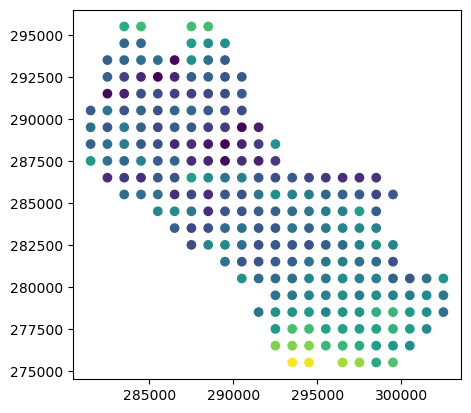

In [144]:
# elev_stats = zonal_stats(
#     grid_1km,
#     dem.values,
#     affine=dem.rio.transform(),
#     stats=["mean"]
# )

# slope_stats = zonal_stats(
#     grid_1km,
#     slope_arr,
#     affine=dem.rio.transform(),
#     stats=["mean"]
# )

# aspect_rad = np.deg2rad(aspect_arr)

# sin_aspect = np.sin(aspect_rad)
# cos_aspect = np.cos(aspect_rad)

# sin_stats = zonal_stats(
#     grid_1km,
#     sin_aspect,
#     affine=dem.rio.transform(),
#     stats=["mean"]
# )

# cos_stats = zonal_stats(
#     grid_1km,
#     cos_aspect,
#     affine=dem.rio.transform(),
#     stats=["mean"]
# )

# mean_aspect = np.rad2deg(
#     np.arctan2(
#         [s["mean"] for s in sin_stats],
#         [c["mean"] for c in cos_stats]
#     )
# ) % 360

gdf["elevation"] = [z["mean"] for z in elev_stats]
gdf["slope"] = [z["mean"] for z in slope_stats]
gdf["aspect"] = mean_aspect


In [125]:
import xarray as xr

dem_da = xr.DataArray(
    dem_arr,
    dims=("y", "x"),
    coords={
        "y": dem.y.values,
        "x": dem.x.values
    },
    name="elevation"
)

slope_da = xr.DataArray(
    slope_arr,
    dims=("y", "x"),
    coords=dem_da.coords,
    name="slope"
)

aspect_da = xr.DataArray(
    aspect_arr,
    dims=("y", "x"),
    coords=dem_da.coords,
    name="aspect"
)

aspect_da

<xarray.DataArray 'aspect' (y: 4100, x: 4210)> Size: 138MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y        (y) float64 33kB 2.956e+05 2.956e+05 ... 2.751e+05 2.751e+05
  * x        (x) float64 34kB 2.815e+05 2.815e+05 ... 3.026e+05 3.026e+05

In [7]:
# Define location of DEM
dem_path = data_dir + "dem_Dolwen.tif"

# 1. Load DEM
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

# 2. Get grid resolution    
dx = transform.a   # pixel width
dy = -transform.e  # pixel height (positive)    

# 3. Compute slope + aspect (drop-in replacement)
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)

# Slope (degrees)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Aspect (degrees, 0–360)
aspect_arr = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect_arr = np.where(aspect_arr < 0, 360 + aspect_arr, aspect_arr)

#from scipy.ndimage import generic_filter

# def tri_func(window):
#     center = window[len(window)//2]
#     return np.mean(np.abs(window - center))

# tri_arr = generic_filter(dem_arr, tri_func, size=3)

### Define a 1km grid based on the rainfall data (to use for aggregating terrain data)

In [118]:
# Get coordinates
x = HAD_ann.projection_x_coordinate.values
y = HAD_ann.projection_y_coordinate.values

# Get resolution (assumes regular grid)
dx = np.abs(x[1] - x[0])
dy = np.abs(y[1] - y[0])

# Build polygons
polys = []
for xi in x:
    for yi in y:
        polys.append(box(xi - dx/2, yi - dy/2,
                         xi + dx/2, yi + dy/2))

# Create GeoDataFrame
grid_1km = gpd.GeoDataFrame(geometry=polys, crs=HAD_Dolwen_ppn.rio.crs)

# Clip to catchment
grid_1km = gpd.overlay(grid_1km, catchment_Dolwen[["geometry"]], how="intersection")
grid_1km = grid_1km.reset_index(drop=True)

### Summarise slope/aspect/elevation inside each 1km grid cell

Could this just be done with regridding?

In [112]:
grid_1km = gdf

In [113]:
# Step 1: Give each pixel an ID
grid_1km["zone_id"] = np.arange(len(grid_1km))

# Step 2: Rasterise polygons, so each pixel stores its grid ID
zone_raster = rasterize(
    [(geom, value) for geom, value in zip(grid_1km.geometry, grid_1km.zone_id)],
    out_shape=dem_arr.shape,
    transform=transform,
    fill=-1,   # background
    dtype="int32")

# Step 3: Convert to xarray (so zone map is an xarray object, same shape as the DEM, slope and aspect)
zones = xr.DataArray(zone_raster, dims=("y", "x"))
dem_xr = xr.DataArray(dem_arr, dims=("y", "x"))
slope_xr = xr.DataArray(slope_arr, dims=("y", "x"))
aspect_xr = xr.DataArray(aspect_arr, dims=("y", "x"))

# Step 4: Mask out irrelevant pixels
mask = zones >= 0
zones = zones.where(mask)
dem_xr = dem_xr.where(mask)
slope_xr = slope_xr.where(mask)
aspect_xr = aspect_xr.where(mask)

# Group all DEM pixels by their zone_id
dem_stats = dem_xr.groupby(zones)

# Step 6: Compute stats
### Elevation
dem_df = xr.Dataset({"mean_dem": dem_stats.mean(), "min_dem": dem_stats.min(),"max_dem": dem_stats.max(),  
                     "std_dem": dem_stats.std()}).to_dataframe()

#### Slope
slope_df = xr.Dataset({"mean_slope": slope_xr.groupby(zones).mean(),
    "std_slope": slope_xr.groupby(zones).std()}).to_dataframe()

### Aspect
aspect_df = xr.Dataset({"mean_aspect": aspect_xr.groupby(zones).mean(),
    "std_aspect": aspect_xr.groupby(zones).std()}).to_dataframe()


/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeW

/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeW

/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kv25483/anaconda3/envs/futureflood_clean/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeW

### Contain one dataset which includes all of the variables for each 1km grid cell within the catchment

In [107]:
# grid_1km = (grid_1km
#         .merge(dem_df, left_index=True, right_index=True)
#           .merge(aspect_df, left_index=True, right_index=True)
#           .merge(slope_df,  left_index=True, right_index=True))

# grid_1km["aspect_sin"] = np.sin(np.deg2rad(grid_1km["mean_aspect"]))
# grid_1km["aspect_cos"] = np.cos(np.deg2rad(grid_1km["mean_aspect"]))

# cell_centroids = grid_1km.geometry.centroid

# grid_1km["x_coord"] = cell_centroids.x
# grid_1km["y_coord"] = cell_centroids.y

grid_1km

,geometry,zone_id,mean_dem,min_dem,max_dem,std_dem,mean_aspect,std_aspect,mean_slope,std_slope,aspect_sin,aspect_cos,x_coord,y_coord
0.0,"POLYGON ((282000 288000, 282000 287225, 281900...",0,693.381764,641.000000,737.919983,22.761830,102.051837,32.938430,10.369478,3.673677,0.977959,-0.208797,281828.099704,287707.308149
1.0,"POLYGON ((282000 288000, 281675 288000, 281675...",1,683.087329,640.000000,722.150024,15.785904,90.423094,45.790982,10.421278,4.924927,0.999973,-0.007384,281870.320986,288235.479497
2.0,"POLYGON ((282000 290000, 282000 289125, 281975...",2,624.351838,610.049988,634.590027,6.319784,136.759299,114.411399,3.922135,2.310703,0.685065,-0.728482,281922.588453,289574.946510
3.0,"POLYGON ((282000 290000, 281975 290000, 281975...",3,613.545601,612.530029,614.380005,0.388215,194.610670,105.069067,2.550742,1.268820,-0.252250,-0.967662,281987.500050,290037.500050
4.0,"POLYGON ((283000 287000, 283000 286275, 282975...",4,494.494480,414.890015,575.599976,39.728365,122.505360,75.795687,13.360867,7.449904,0.843341,-0.537379,282745.709547,286740.507846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221.0,"POLYGON ((301000 279000, 301000 280000, 302000...",221,433.948214,335.470001,523.059998,51.538330,250.786166,62.715058,15.841639,7.855450,-0.944297,-0.329095,301500.000000,279500.000000
222.0,"POLYGON ((302000 280000, 301000 280000, 301000...",222,497.824147,362.799988,566.960022,46.376399,228.746567,50.538018,12.016552,6.598232,-0.751800,-0.659391,301472.143078,280343.673464
223.0,"MULTIPOLYGON (((302000 279000, 302175 279000, ...",223,529.767091,523.570007,535.559998,2.500510,180.983665,155.078241,4.198881,1.598235,-0.017167,-0.999853,302075.378814,278921.590874
224.0,"POLYGON ((302000 279000, 302000 280000, 302525...",224,537.150137,494.420013,569.859985,15.889248,264.466458,53.549380,7.435491,3.442309,-0.995340,-0.096428,302209.046487,279581.418088


### Keep only cells with a substantial portion of cell within catchment

In [12]:
grid_1km["cell_area"] = grid_1km.geometry.area

intersection = gpd.overlay(grid_1km,catchment_Dolwen[["geometry"]],how="intersection")

intersection["intersect_area"] = intersection.geometry.area

grid_1km = grid_1km.merge(intersection.groupby(intersection.index)["intersect_area"].sum(),left_index=True,right_index=True,
                            how="left")

grid_1km["intersect_area"] = grid_1km["intersect_area"].fillna(0)

grid_1km["coverage"] = grid_1km["intersect_area"] / grid_1km["cell_area"]

grid_1km = grid_1km[grid_1km["coverage"] >= 0.5]
grid_1km = grid_1km[grid_1km['intersect_area']>100000].copy()
len(grid_1km)

208

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Implement a cluster analysis </h3>
    
This is designed to find the best way to partition the 1km grid cells into groups which have similar environmental characteristics.    
    
 - Define the optimal number of clusters using silhouette scores
 - Run the cluster analysis
    
  </div>    
</div>

In [13]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = grid_1km[["mean_dem", "mean_slope","aspect_sin","aspect_cos",]]# "x_coord", "y_coord"]]
scaler = StandardScaler()
X = scaler.fit_transform(features)

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.27454230693778914
3 0.279364184207456
4 0.24562322520958843
5 0.22429993700617012
6 0.2233826671900756
7 0.22720506990873343
8 0.23923432382803672
9 0.2386470912702017


#### Run the cluster analysis

In [14]:
k = 10  # start here
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X)

# Attach labels back to data
grid_1km["cluster"] = labels

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Decide on one grid cell to represent each cluster </h3>
    
Find one cell to represent each cluster, with constraint on proximity to each other
    
  </div>    
</div>

#### Get the locations of the existing gauges

In [19]:
existing_gauges = rain_meta_sf.to_crs(grid_1km.crs)
existing_coords = np.array([(g.x, g.y) for g in existing_gauges.geometry])

existing_coords = np.asarray(existing_coords)

cell_coords = np.array([(geom.x, geom.y) for geom in cell_centroids.geometry])

#### For each cluster: get a list of the grid cells in order of how well they represent the cluster

In [16]:
# ------------------------------------ #
# For each of the clusters, find a list of the cells which 
# would best represent the cluster, in order of appropriateness
# This is based on: how close each grid cell is to the cluster centroid (in feature space)
# ------------------------------------ #
cluster_candidates = {}

# Loop through each grid cell (and the cluster label assigned to it)
for c in np.unique(labels):
    cluster_idx = np.where(labels == c)[0]
    cluster_points = X[cluster_idx]
    
    centroid = kmeans.cluster_centers_[c]
    
    # distances to centroid
    distances = np.linalg.norm(cluster_points - centroid, axis=1)
    
    # sort candidates (best first)
    sorted_idx = cluster_idx[np.argsort(distances)]
    
    cluster_candidates[c] = sorted_idx

#### For each cluster: select a grid cell to represent it, based on ordering above and also spatial proximity to each other

In [23]:
min_dist=2500

In [39]:
print(f"Selected clusters: {len(greedy_solution)}")
print(f"Failed clusters: {len(failed)}")

print("\nExamples of failed clusters:")
for k in list(failed.keys())[:10]:
    print(k, failed[k])

Selected clusters: 9
Failed clusters: 1

Examples of failed clusters:
9 no_valid_candidate


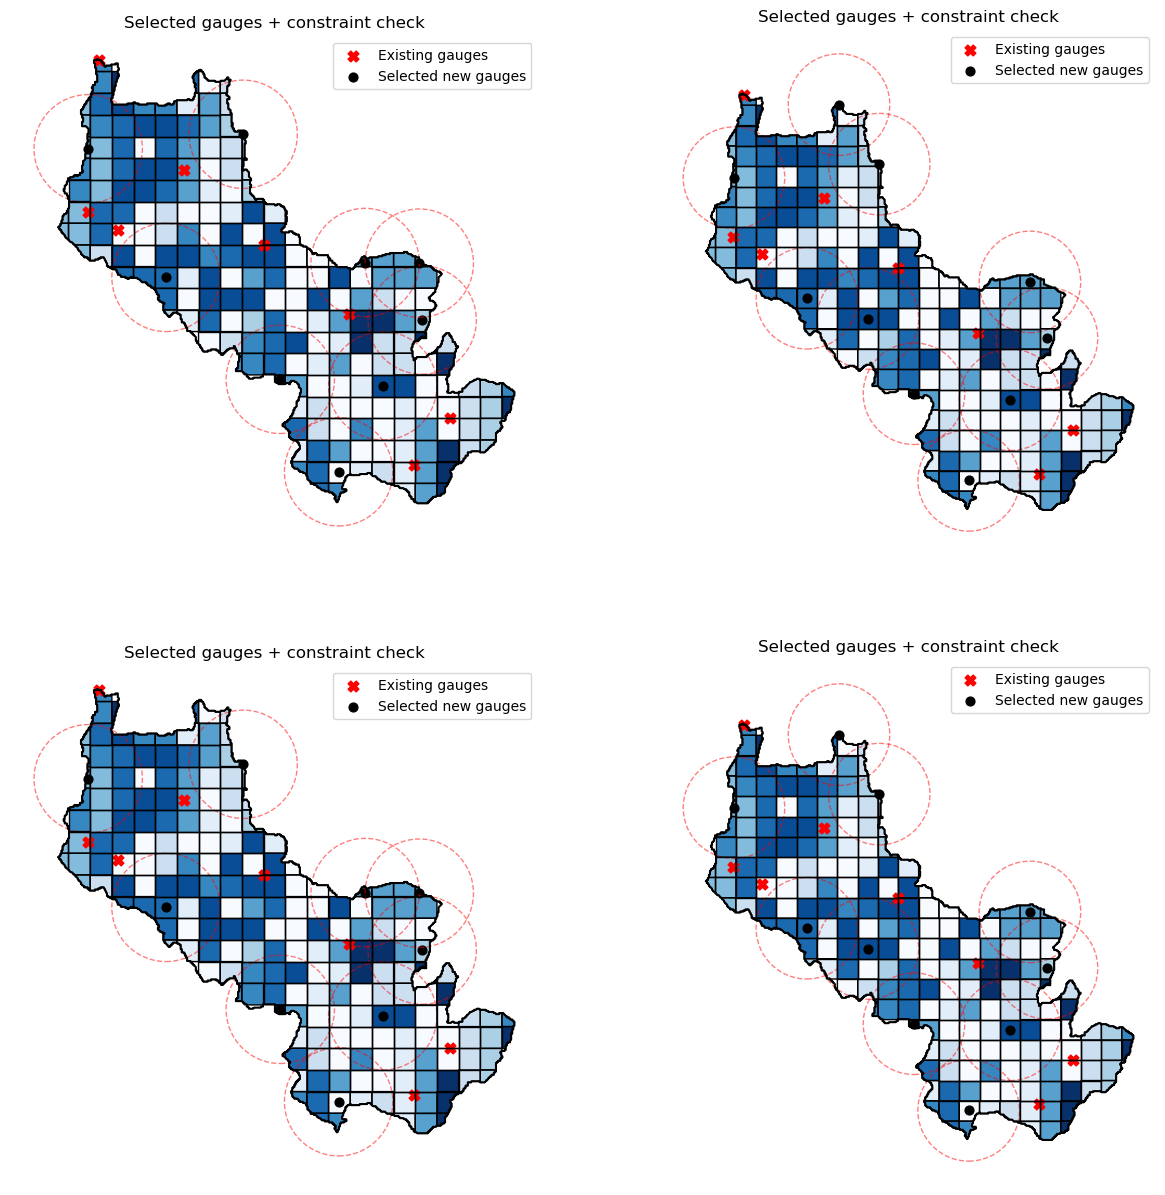

In [54]:
# 1. greedy baseline
# greedy_solution = greedy_selection(cluster_candidates,cell_coords,existing_coords,min_dist)
greedy_solution, failed = greedy_selection(cluster_candidates,cell_coords,existing_coords,min_dist)

# # 2. shuffle-greedy improvement
# shuffle_solution = shuffle_greedy(cluster_candidates,cell_coords,existing_coords,min_dist,n_iterations=500)

# # 3 Simulated annealin
# sa_solution = simulated_annealing(greedy_solution,cluster_candidates,cell_coords,existing_coords,min_dist)

# # 4. ILP
# ilp_solution_result = ilp_solution(cluster_candidates,cell_coords,existing_coords,min_dist)

# 3. check both
fig,axs=plt.subplots(ncols=2, nrows=2, figsize=(15,15))
axs=axs.flatten()

#print("\n--- GREEDY ---")
plot_and_check(greedy_solution, cell_centroids, existing_coords, min_dist, ax=axs[0])
axs[0].axis('off')

#print("\n--- SHUFFLE GREEDY ---")
plot_and_check(shuffle_solution, cell_centroids, existing_coords, min_dist, ax=axs[1])
axs[1].axis('off')

#print("\n--- Simulated annealing ---")
plot_and_check(sa_solution, cell_centroids, existing_coords, min_dist, ax=axs[2])
axs[2].axis('off')

#print("\n--- ILP ---")
plot_and_check(ilp_solution_result, cell_centroids, existing_coords, min_dist, ax=axs[3])
axs[3].axis('off');

In [55]:
# ── Shared scoring function ──────────────────────────────────────────────────
def evaluate_solution(selected_cells, cluster_candidates, cell_centroids, 
                      existing_coords, min_dist):
    """
    Returns a dict of diagnostics for a given solution.
    """
    results = {}
    
    # 1. Coverage: how many clusters got a gauge
    results["n_covered"] = len(selected_cells)
    results["n_clusters"] = len(cluster_candidates)
    results["coverage_pct"] = 100 * len(selected_cells) / len(cluster_candidates)
    
    # 2. Candidate quality: average rank of chosen candidates
    #    (0 = top candidate chosen, higher = had to fall back)
    ranks = []
    for c, sel in zip(cluster_candidates.keys(), selected_cells):
        candidates = list(cluster_candidates[c])
        if sel in candidates:
            ranks.append(candidates.index(sel))
        else:
            ranks.append(np.nan)
    results["mean_candidate_rank"] = np.nanmean(ranks)
    results["max_candidate_rank"]  = np.nanmax(ranks)
    results["rank_details"] = dict(zip(cluster_candidates.keys(), ranks))
    
    # 3. Spacing: min distance between any two selected gauges
    if len(selected_cells) > 1:
        coords = np.array([
            (cell_centroids.iloc[i].x, cell_centroids.iloc[i].y)
            for i in selected_cells
        ])
        dm = cdist(coords, coords)
        np.fill_diagonal(dm, np.inf)
        results["min_spacing_selected"] = dm.min()
        results["any_spacing_violation"] = bool((dm < min_dist).any())
    else:
        results["min_spacing_selected"] = np.nan
        results["any_spacing_violation"] = False
    
    # 4. Spacing vs existing gauges
    violations = []
    for i, idx in enumerate(selected_cells):
        pt = cell_centroids.iloc[idx]
        for ex in existing_coords:
            dist = np.linalg.norm(np.array([pt.x, pt.y]) - ex)
            if dist < min_dist:
                violations.append((i, dist))
    results["existing_gauge_violations"] = violations
    results["any_existing_violation"] = len(violations) > 0
    
    return results


def print_evaluation(label, results, runtime):
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Coverage:          {results['n_covered']}/{results['n_clusters']} "
          f"({results['coverage_pct']:.1f}%)")
    print(f"  Mean rank chosen:  {results['mean_candidate_rank']:.2f}  "
          f"(0 = always top candidate)")
    print(f"  Max rank chosen:   {results['max_candidate_rank']:.0f}")
    print(f"  Min gauge spacing: {results['min_spacing_selected']:.0f} m  "
          f"(threshold: {min_dist} m)")
    print(f"  Spacing violation: {results['any_spacing_violation']}")
    print(f"  Existing violation:{results['any_existing_violation']}")
    print(f"  Runtime:           {runtime:.2f}s")
    if results['any_spacing_violation'] or results['any_existing_violation']:
        print("  ⚠️  INVALID SOLUTION — constraint violated")
    else:
        print("  ✅ Valid solution")
    # Show which clusters had to fall back from top candidate
    fallbacks = {c: r for c, r in results['rank_details'].items() if r > 0}
    if fallbacks:
        print(f"  Clusters using fallback candidates: {fallbacks}")


# ── Option 0: your original greedy (baseline) ────────────────────────────────
t0 = time.time()
# ... your original code here, store result in original_cells ...
greedy_cells = list(greedy_solution.values())
original_cells = greedy_cells  # replace with your actual result
t_original = time.time() - t0
res_original = evaluate_solution(original_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
print_evaluation("Option 0: Original greedy (fixed order)", res_original, t_original)


# ── Option 1: shuffle + repeat ───────────────────────────────────────────────
t0 = time.time()
# ... run Option 1, store best result in shuffle_cells ...
shuffle_cells = list(shuffle_solution.values())
t_shuffle = time.time() - t0
res_shuffle = evaluate_solution(shuffle_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
print_evaluation("Option 1: Shuffle + repeat (500 iter)", res_shuffle, t_shuffle)


# ── Option 3: ILP ────────────────────────────────────────────────────────────
t0 = time.time()
# ... run Option 3, store result in ilp_cells (or None if infeasible) ...
ilp_cells = list(ilp_solution_result.values())       # replace with your actual result
t_ilp = time.time() - t0
if ilp_cells is not None:
    res_ilp = evaluate_solution(
        ilp_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
    print_evaluation("Option 3: ILP", res_ilp, t_ilp)
else:
    print("\nOption 3: ILP — INFEASIBLE")
    
# ── Option 3: ILP ────────────────────────────────────────────────────────────
t0 = time.time()
# ... run Option 3, store result in ilp_cells (or None if infeasible) ...
sim_anneal_cells = list(sa_solution.values())
t_sim_anneal = time.time() - t0
if sim_anneal_cells is not None:
    res_sim_anneal = evaluate_solution(
        sim_anneal_cells, cluster_candidates, cell_centroids, existing_coords, min_dist)
    print_evaluation("Option 3: ILP", res_sim_anneal, t_sim_anneal)
else:
    print("\nOption 3: ILP — INFEASIBLE")    


# ── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Original greedy": res_original,
    "Shuffle+repeat":  res_shuffle,
    "Simulated anneal":  res_sim_anneal,
     "ILP":  res_ilp}).T[["n_covered", "coverage_pct", "mean_candidate_rank", 
      "min_spacing_selected", "any_spacing_violation"]]
print("\n", summary.to_string())


  Option 0: Original greedy (fixed order)
  Coverage:          9/10 (90.0%)
  Mean rank chosen:  2.11  (0 = always top candidate)
  Max rank chosen:   6
  Min gauge spacing: 2500 m  (threshold: 2500 m)
  Spacing violation: False
  Existing violation:False
  Runtime:           0.00s
  ✅ Valid solution
  Clusters using fallback candidates: {1: 1, 2: 1, 3: 1, 4: 6, 5: 1, 7: 4, 8: 5}

  Option 1: Shuffle + repeat (500 iter)
  Coverage:          10/10 (100.0%)
  Mean rank chosen:  2.50  (0 = always top candidate)
  Max rank chosen:   5
  Min gauge spacing: 2897 m  (threshold: 2500 m)
  Spacing violation: False
  Existing violation:False
  Runtime:           0.00s
  ✅ Valid solution
  Clusters using fallback candidates: {8: 5}

  Option 3: ILP
  Coverage:          10/10 (100.0%)
  Mean rank chosen:  2.30  (0 = always top candidate)
  Max rank chosen:   6
  Min gauge spacing: 2897 m  (threshold: 2500 m)
  Spacing violation: False
  Existing violation:False
  Runtime:           0.00s
  ✅ Vali

---

### Simulated annealing

---

In [59]:
# simple example
from sklearn.linear_model import LinearRegression

X = np.column_stack([grid_1km['mean_dem'], grid_1km['mean_slope'], grid_1km['mean_aspect']])
y = grid_1km['mean_dem']

model = LinearRegression().fit(X, y)
pred = model.predict(X)

residuals = y - pred

NameError: name 'rainfall' is not defined

In [ ]:
# import seaborn as sns
# sns.pairplot(gauge_locations, vars=["mean_dem", "mean_slope", 'mean_aspect'], hue="cluster", palette = 'viridis')

In [ ]:
# import rasterstats as rs

# rain_stats = rs.zonal_stats(
#     grid_1km,
#     HAD_Dolwen_ppn.mean(dim="time").values,
#     affine=HAD_Dolwen_ppn.rio.transform(),
#     stats="mean",
#     nodata=np.nan
# )

# grid_1km["rain"] = [r["mean"] for r in rain_stats]

In [ ]:
# import numpy as np
# from scipy.spatial.distance import pdist

# # 1. Get centroids
# centroids = grid_1km.geometry.centroid
# coords = np.array([(pt.x, pt.y) for pt in centroids])

# # 2. Get rainfall values
# rain = HAD_Dolwen_ppn.mean(dim="time").values.flatten()
# rain = rain[~np.isnan(rain)]

# # 3. Mask NaNs (CRITICAL)
# mask = ~np.isnan(rain)

# coords = coords[mask]
# values = rain[mask]

# # 4. Now compute distances + differences
# dists = pdist(coords)
# diffs = pdist(values.reshape(-1, 1))

# gamma = 0.5 * (diffs ** 2)

In [ ]:
# bins = np.linspace(0, dists.max(), 20)
# bin_idx = np.digitize(dists, bins)
# # 
# variogram = [gamma[bin_idx == i].mean() for i in range(1, len(bins))]


In [ ]:
# import matplotlib.pyplot as plt

# plt.plot(bins[1:], variogram, 'o-')
# plt.xlabel("Distance (m)")
# plt.ylabel("Semivariance")
# plt.title("Empirical Variogram")
# plt.show()

In [ ]:
# grid_1km_sf["max_elev"]   = [z["max"]  for z in dem_stats]
# grid_1km_sf["min_elev"]   = [z["min"]  for z in dem_stats]
# grid_1km_sf["mean_elev"]  = [z["mean"] for z in dem_stats]
# grid_1km_sf["var_elev"]   = [z["std"]**2 if z["std"] is not None else np.nan for z in dem_stats]
# grid_1km_sf["range_elev"] = grid_1km_sf["max_elev"] - grid_1km_sf["min_elev"]

# grid_1km_sf["mean_slope"] = [z["mean"] for z in slope_stats]
# grid_1km_sf["var_slope"]  = [z["std"]**2 if z["std"] is not None else np.nan for z in slope_stats]

# grid_1km_sf["mean_aspect"]= [z["mean"] for z in aspect_stats]
# grid_1km_sf["var_aspect"] = [z["std"]**2 if z["std"] is not None else np.nan for z in aspect_stats]

# grid_1km_sf["mean_tri"]   = [z["mean"] for z in tri_stats]
# grid_1km_sf["var_tri"]    = [z["std"]**2 if z["std"] is not None else np.nan for z in tri_stats]

# grid_1km_sf["mean_PPN"]   = [z["mean"] for z in ppn_stats]

# # ==============================================================
# Point grid and rain gauge spatial joins
# ==============================================================

# Intersect grid polygons with centroid points → keep terrain attributes per point
# point_1km_sf = gpd.sjoin(grid_1km_sf, grid_1km_point, how="inner", predicate="contains")
# point_1km_sf["x"] = grid_1km_xy[:, 0]
# point_1km_sf["y"] = grid_1km_xy[:, 1]

# # Join rain gauge metadata with grid cell attributes
# rain_meta_sf2 = gpd.sjoin(rain_meta_sf, grid_1km_sf, how="left", predicate="within")
# rain_meta_sf2 = rain_meta_sf2.iloc[:, :12]  # keep first 12 columns (matching R)

# rain_xy = np.array([(g.x, g.y) for g in rain_meta_sf2.geometry])
# rain_meta_sf2["x"] = rain_xy[:, 0]
# rain_meta_sf2["y"] = rain_xy[:, 1]

In [ ]:
# HAD_Dolwen_ppn_mean
# values = HAD_Dolwen_ppn.mean(dim="time").values.flatten()
# values.shape

In [ ]:
# # ==============================================================
# # Plot: rain gauges, river network, mean rainfall, grid
# # ==============================================================

# fig, ax = plt.subplots(figsize=(10, 10))

# # Mean rainfall raster
# HAD_Dolwen_ppn_mean.plot( ax=ax,cmap="magma", alpha=0.8,add_colorbar=True,robust=True)

# # Grid outlines
# grid_1km.boundary.plot(ax=ax, color="grey", linewidth=1)

# # River network
# # river_net_Dolwen.plot(ax=ax, color="steelblue", linewidth=0.8)

# # Rain gauges
# rain_meta_sf.plot(ax=ax, color="red", markersize=30, zorder=5)

# plt.title("Mean Annual Rainfall with Rain Gauges and Grid")
# plt.tight_layout()
# plt.show()

In [ ]:
# # ==============================================================
# # Create 1km polygon grid and centroid points
# # ==============================================================

# # Build 1km grid polygons clipped to catchment
# from shapely.geometry import box

# # Get raster bounds and build grid
# xmin, ymin, xmax, ymax = catchment_Dolwen.total_bounds
# cell_size = 1000

# cols = np.arange(xmin, xmax, cell_size)
# rows = np.arange(ymin, ymax, cell_size)

# grid_polys = [box(x, y, x + cell_size, y + cell_size)
#     for x in cols for y in rows]

# grid_1km = gpd.GeoDataFrame(geometry=grid_polys, crs=ukgrid)

# # Clip grid to catchment boundary
# grid_1km = gpd.overlay(grid_1km, catchment_Dolwen[["geometry"]], how="intersection")
# grid_1km = grid_1km.reset_index(drop=True)

# # Get centroids
# grid_1km_point = grid_1km.copy()
# grid_1km_point["geometry"] = grid_1km.centroid

# # Extract XY coordinates
# grid_1km_xy = np.array(
#     [(geom.x, geom.y) for geom in grid_1km_point.geometry])

# # Quick plot to check
# plt.scatter(grid_1km_xy[:, 0], grid_1km_xy[:, 1], s=2)
# plt.title("1km Grid Centroids")
# plt.axis("equal")
# plt.show()